<a href="https://colab.research.google.com/github/eshernan/big-data-postgraduate/blob/main/supersalud/ProfesorSesion2SuperSalud_BigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Descargar el archivo directamente desde el sitio de supersalud

In [ ]:
import requests

url = "https://mapas.supersalud.gov.co/arcgisportal/sharing/rest/content/items/b52330a16b3940c39d38cb164c9dc014/data"
output_file = "/content/Reclamos_2024_python.csv"

# Realiza la petición con verificación SSL deshabilitada (-k en curl)
response = requests.get(url, allow_redirects=True, verify=False)

# Guardar el archivo
with open(output_file, "wb") as f:
    f.write(response.content)

print(f"Archivo descargado en: {output_file}")


Archivo descargado en: /content/Reclamos_2024_python.csv


In [ ]:
!du -sh /content/Reclamos_2024_python.csv

550M	/content/Reclamos_2024_python.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls -lh /content/drive/MyDrive/supersalud/

total 550M
-rw------- 1 root root 550M Aug 11 18:01 Reclamos_2024.csv


In [ ]:
!cp /content/drive/MyDrive/supersalud/Reclamos_2024.csv /content/

In [ ]:
!du -sh /content/Reclamos_2024.csv

550M	/content/Reclamos_2024.csv


In [ ]:
# !curl -L -k  https://mapas.supersalud.gov.co/arcgisportal/sharing/rest/content/items/b52330a16b3940c39d38cb164c9dc014/data -o /content/Reclamos_2024.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  549M  100  549M    0     0  38.8M      0  0:00:14  0:00:14 --:--:-- 42.5M


In [ ]:
!du -sh  Reclamos_2024.csv

550M	Reclamos_2024.csv


In [ ]:
!head Reclamos_2024.csv

﻿OBJECTID,periodo,mes,pqr_canal,pet_cod_depto,pet_cod_mpio,id_afec,afec_parentesco,afec_genero,afec_edad,afec_edadr,afec_educ,afec_regafiliacion,afec_getnico,afec_pobespecial,afec_cod_depto,afec_cod_mpio,ent_nombre,ent_tipovig_sns,ent_cod_sns,ent_alias_sn,ent_cod_depto,ent_cod_mpio,cod_macromot,macromotivo,cod_motgen,motivo_general,cod_motesp,motivo_especifico,cod_tipo_motesp,tipo_de_motivo_especifico,cod_subtipo_motesp,subtipo_de_motivo_especifico,patologia_1,patologia_tipo,cie_10,alto_costo,clasificacion_de_riesgo
1,2024,6,Telefónico,5,5001,US- 000003606236,Hijo (A),HOMBRE,73,MAYOR DE 63 AÑOS ,Primaria Incompleta,Contributivo,Afrocolombiano o Afrodescendiente,No Aplica,5,5001,SAVIA SALUD,RÉGIMEN SUBSIDIADO,EPSS40,SAVIA SALUD EPS,5,5001,1,BARRERAS EN EL ACCESO A TECNOLOGÍAS Y SERVICIOS DE SALUD; Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO,103,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TECNOLOGÍAS EN SALUD Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARI

### Aqui se ve el tamaño del archivo csv

In [ ]:
reclamos_df=pd.read_csv('raw/Reclamos_2024_latin1.csv')

In [ ]:
reclamos_df.to_csv('raw/Reclamos_2024_latin1.csv', index=False)

## Analisis de tipos de formatos para fechas, horas y zonas horarias
24/02/05
24/05/02
05/02/24
2025-05-03:13:33:88
YYYY-MM-DD:HH:MM:ss


14:00:00 (COL)
 ->            Munich ?

TimeZone, 14:00:00 GMT-5, UTC
           12:00:00 PST

Date.apply(pd.to_datetime, format='%d/%m/%Y')
format='%Y-%m-%d %H:%M:%S.%f')

In [ ]:
!head raw/Reclamos_2024_utf8.csv

OBJECTID,periodo,mes,pqr_canal,pet_cod_depto,pet_cod_mpio,id_afec,afec_parentesco,afec_genero,afec_edad,afec_edadr,afec_educ,afec_regafiliacion,afec_getnico,afec_pobespecial,afec_cod_depto,afec_cod_mpio,ent_nombre,ent_tipovig_sns,ent_cod_sns,ent_alias_sn,ent_cod_depto,ent_cod_mpio,cod_macromot,macromotivo,cod_motgen,motivo_general,cod_motesp,motivo_especifico,cod_tipo_motesp,tipo_de_motivo_especifico,cod_subtipo_motesp,subtipo_de_motivo_especifico,patologia_1,patologia_tipo,cie_10,alto_costo,clasificacion_de_riesgo
1,2024,6,Telefónico,5.0,5001.0,US- 000003606236,Hijo (A),HOMBRE,73,MAYOR DE 63 AÑOS ,Primaria Incompleta,Contributivo,Afrocolombiano o Afrodescendiente,No Aplica,5,5001,SAVIA SALUD,RÉGIMEN SUBSIDIADO,EPSS40,SAVIA SALUD EPS,5,5001,1,BARRERAS EN EL ACCESO A TECNOLOGÍAS Y SERVICIOS DE SALUD; Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO,103,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TECNOLOGÍAS EN SALUD Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USU

<Axes: >

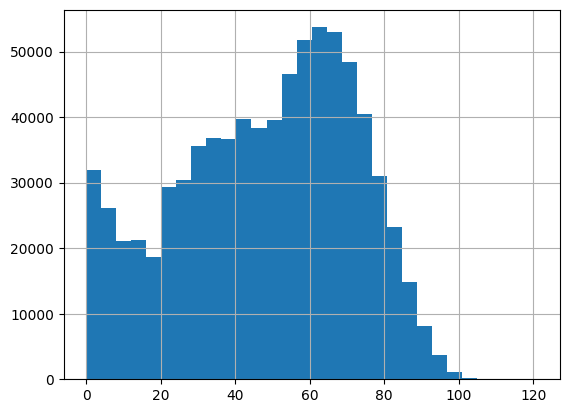

In [ ]:
reclamos_df['afec_edad'].hist(bins=30)

In [ ]:
reclamos_df.size

29700838

In [ ]:
reclamos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781601 entries, 0 to 781600
Data columns (total 38 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OBJECTID                      781601 non-null  int64  
 1   periodo                       781601 non-null  int64  
 2   mes                           781601 non-null  int64  
 3   pqr_canal                     781601 non-null  object 
 4   pet_cod_depto                 779485 non-null  float64
 5   pet_cod_mpio                  779485 non-null  float64
 6   id_afec                       781601 non-null  object 
 7   afec_parentesco               781601 non-null  object 
 8   afec_genero                   781601 non-null  object 
 9   afec_edad                     781601 non-null  int64  
 10  afec_edadr                    781601 non-null  object 
 11  afec_educ                     781601 non-null  object 
 12  afec_regafiliacion            781601 non-nul

In [ ]:
memory_bytes = reclamos_df.memory_usage(deep=True).sum()

In [ ]:
print(memory_bytes)

1760279004


In [ ]:
reclamos_df.to_parquet('Reclamos_2024.parquet')

In [ ]:
!du -sh  Reclamos_2024.parquet

26M	Reclamos_2024.parquet


In [ ]:
!head Reclamos_2024.parquet

 
 
 
 
 
 
 
 
 
 


## Asignar los tipos de datos correctos
Al asignar los tipos de datos correctos, se puede:
- Optimizar el almacenamiento
- usar efectivamente los índices
- Acelerar las búsquedas
- Optimizar la distribución



| Columna                         | Tipo de dato recomendado | Justificación                                     |
| ------------------------------- | ------------------------ | ------------------------------------------------- |
| OBJECTID                        | `Int32`  #para borrar                | Identificador entero, admite millones de filas.   |
| periodo                         | `Int16`                  | Año (pocos valores, particionable).               |
| mes                             | `Int8`                   | Mes (1–12), bajo rango.                           |
| pqr\_canal                      | `category[string]`       | Vocabulario corto (Telefónico, Web, etc.).        |
| pet\_cod\_depto                 | `Int16` (nullable)       | Código de departamento, admite nulos.             |
| pet\_cod\_mpio                  | `Int32` (nullable)       | Código de municipio, admite nulos.                |
| id\_afec                        | `string`                 | Identificador único alfanumérico.                 |
| afec\_parentesco                | `category[string]`       | Relación familiar (Hijo, Cónyuge, etc.).          |
| afec\_genero                    | `category[string]`       | Género (HOMBRE, MUJER).                           |
| afec\_edad                      | `Int16`                  | Edad numérica (0–120 típico).                     |
| afec\_edadr                     | `category[string]`       | Rango de edad (ej. “MAYOR DE 63 AÑOS”).           |
| afec\_educ                      | `category[string]`       | Nivel educativo (Primaria, Secundaria, etc.).     |
| afec\_regafiliacion             | `category[string]`       | Régimen de afiliación (Contributivo, Subsidiado). |
| afec\_getnico                   | `category[string]`       | Grupo étnico.                                     |
| afec\_pobespecial               | `category[string]`       | Población especial (discapacidad, etc.).          |
| afec\_cod\_depto                | `Int16`                  | Código depto (completo, sin nulos).               |
| afec\_cod\_mpio                 | `Int32`                  | Código municipio (completo, sin nulos).           |
| ent\_nombre                     | `category[string]`       | Nombre de EPS, vocabulario limitado.              |
| ent\_tipovig\_sns               | `category[string]`       | Tipo de régimen (Subsidiado/Contributivo).        |
| ent\_cod\_sns                   | `string`                 | Código alfanumérico de EPS.                       |
| ent\_alias\_sn                  | `category[string]`       | Alias corto de EPS.                               |
| ent\_cod\_depto                 | `Int16`                  | Depto de EPS.                                     |
| ent\_cod\_mpio                  | `Int32`                  | Municipio de EPS.                                 |
| cod\_macromot                   | `Int16`                  | Código de macromotivo (catálogo).                 |
| macromotivo                     | `category[string]`       | Texto asociado a macromotivo.                     |
| cod\_motgen                     | `Int16`                  | Código de motivo general.                         |
| motivo\_general                 | `category[string]`       | Texto de motivo general.                          |
| cod\_motesp                     | `Int16`                  | Código de motivo específico.                      |
| motivo\_especifico              | `category[string]`       | Texto de motivo específico.                       |
| cod\_tipo\_motesp               | `Int16` (nullable)       | Código de tipo de motivo específico (con nulos).  |
| tipo\_de\_motivo\_especifico    | `category[string]`       | Texto de tipo de motivo específico.               |
| cod\_subtipo\_motesp            | `Int16` (nullable)       | Código de subtipo de motivo (con nulos).          |
| subtipo\_de\_motivo\_especifico | `category[string]`       | Texto de subtipo (con nulos).                     |
| patologia\_1                    | `category[string]`       | Patología principal (catálogo).                   |
| patologia\_tipo                 | `category[string]`       | Tipo de patología (catálogo).                     |
| cie\_10                         | `category[string]`       | Código CIE-10, altamente repetido.                |
| alto\_costo                     | `category[string]`       | Clasificación de alto costo (Sí, No aplica).      |
| clasificacion\_de\_riesgo       | `category[string]`       | Nivel de riesgo (SIMPLE, PRIORIZADO).             |

---


In [ ]:
reclamos_quality_df = pd.read_csv('Reclamos_2024.csv', na_values=['', 'NA', 'N/A', 'NO APLICA', 'NOAPLICA'])

dtype_mapping = {
    'OBJECTID': 'Int64',
    'periodo': 'Int16',
    'mes': 'Int8',
    'pet_cod_depto': 'Int8',
    'pet_cod_mpio': 'Int32',
    'afec_edad': 'Int32',
    'afec_cod_depto': 'Int32',
    'afec_cod_mpio': 'Int32',
    'ent_cod_sns': 'string',
    'ent_cod_depto': 'Int32',
    'ent_cod_mpio': 'Int32',
    'cod_macromot': 'Int32',
    'cod_motgen': 'Int32',
    'cod_motesp': 'Int32',
    'cod_tipo_motesp': 'Int32',
    'cod_subtipo_motesp': 'Int32'
}

for col, dtype in dtype_mapping.items():
    if dtype.startswith('Int'):
        reclamos_quality_df[col] = pd.to_numeric(reclamos_quality_df[col], errors='coerce').astype(dtype)
    else:
        reclamos_quality_df[col] = reclamos_quality_df[col].astype(dtype)

# Convertir los objetos en Categorias
categorical_cols = [
    'pqr_canal', 'afec_parentesco', 'afec_genero', 'afec_edadr', 'afec_educ',
    'afec_regafiliacion', 'afec_getnico', 'afec_pobespecial', 'ent_nombre',
    'ent_tipovig_sns', 'ent_alias_sn', 'macromotivo', 'motivo_general',
    'motivo_especifico', 'tipo_de_motivo_especifico',
    'subtipo_de_motivo_especifico', 'patologia_1', 'patologia_tipo',
    'cie_10', 'alto_costo', 'clasificacion_de_riesgo'
]

for col in categorical_cols:
    # Vallidar si la columna existe antes de convertir
    if col in reclamos_quality_df.columns:
        reclamos_quality_df[col] = reclamos_quality_df[col].astype('category')

#Borrar campos innecesarios
reclamos_quality_df.drop(columns=['OBJECTID'], inplace=True)
#Mostrar nuevos tipos y tamaño
display(reclamos_quality_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781601 entries, 0 to 781600
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   periodo                       781601 non-null  Int16   
 1   mes                           781601 non-null  Int8    
 2   pqr_canal                     781601 non-null  category
 3   pet_cod_depto                 779485 non-null  Int8    
 4   pet_cod_mpio                  779485 non-null  Int32   
 5   id_afec                       781601 non-null  object  
 6   afec_parentesco               781601 non-null  category
 7   afec_genero                   781601 non-null  category
 8   afec_edad                     781601 non-null  Int32   
 9   afec_edadr                    781601 non-null  category
 10  afec_educ                     781601 non-null  category
 11  afec_regafiliacion            781601 non-null  category
 12  afec_getnico                  

None

## Analizando los datos nulos o no existentes

In [ ]:
print('Campos sin valores,  o valores no existentes')
display(reclamos_quality_df.isna().sum())
print('Campos con valores nulos')
display(reclamos_quality_df.isnull().sum())


Campos sin valores,  o valores no existentes


,0
periodo,0
mes,0
pqr_canal,0
pet_cod_depto,2116
pet_cod_mpio,2116
id_afec,0
afec_parentesco,0
afec_genero,0
afec_edad,0
afec_edadr,0


Campos con valores nulos


,0
periodo,0
mes,0
pqr_canal,0
pet_cod_depto,2116
pet_cod_mpio,2116
id_afec,0
afec_parentesco,0
afec_genero,0
afec_edad,0
afec_edadr,0


## Analisis de los campos
 - Existen valores faltantes ***NA, No/Hay, "", No Aplica, No Hay***
 - Existen Valores Nulos
## Que hacer con estos valores?
- Entenderlos (Numérica y gráficamente)
- Decidir como completarlos, aceptarlos, eliminarlos, o descartarlos.


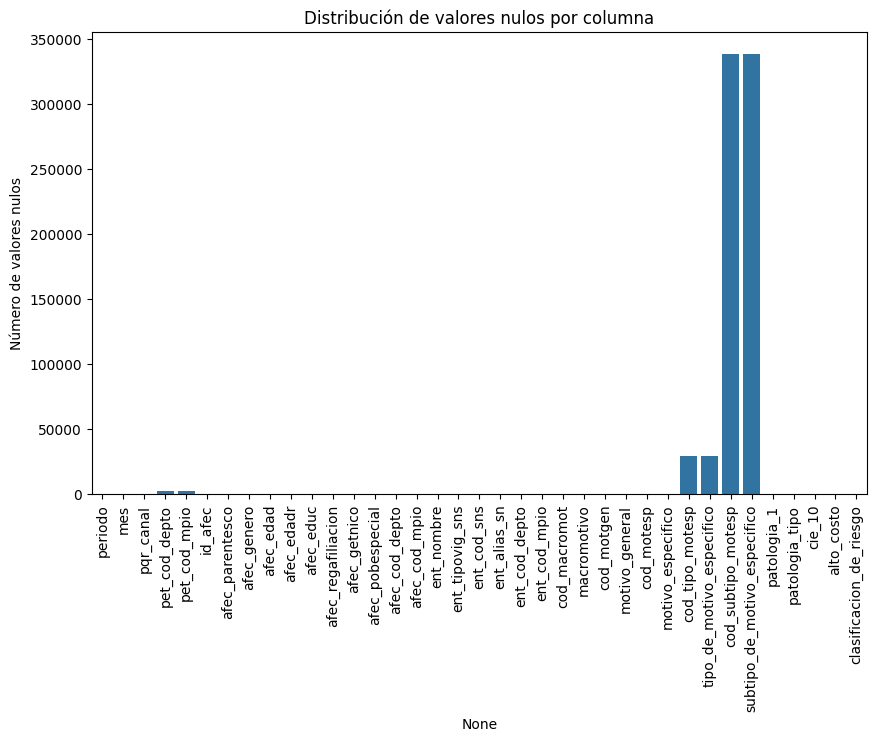

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo de valores nulos por columna
missing_values = reclamos_quality_df.isna().sum()

# Gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.ylabel("Número de valores nulos")
plt.title("Distribución de valores nulos por columna")
plt.show()

Depende de la naturaleza del campo y del análisis que quieras realizar:

pet_cod_depto y pet_cod_mpio (2116 nulos)
→ Representan ubicación. Se puede:

- Rellenar con "DESCONOCIDO" o un código especial.

- Si tienes otra variable asociada (ej. afec_cod_depto), intentar imputar con esa.(equivalencias)

cod_tipo_motesp y tipo_de_motivo_especifico (~29k nulos)
→ Puede ser que no siempre aplique un tipo de motivo. Se podría:

- Dejar como NaN y marcar como "no aplica".

- Crear una categoría "SIN_TIPO".

cod_subtipo_motesp y subtipo_de_motivo_especifico (~338k nulos)
- Aquí la cantidad es muy grande. Es probable que solo un subconjunto de reclamos llegue a nivel de submotivo. Se puede:

- Asumir que el NaN significa "no detallado".

- No imputar, pero sí usar el % de detalle como indicador de calidad del registro.

## Analizando las series de tiempo (Periodos)
- Permite entender los periodos donde más se presentan faltantes
- Permite analizar si fueron periodos de inestabilidad

In [ ]:
# Agrupar por periodo y contar nulos en cada campo
missing_by_period = reclamos_quality_df.groupby(["periodo","mes"]).apply(lambda x: x.isna().sum())

print(missing_by_period.head())

             periodo  mes  pqr_canal  pet_cod_depto  pet_cod_mpio  id_afec  \
periodo mes                                                                  
2024    1          0    0          0            402           402        0   
        2          0    0          0            371           371        0   
        3          0    0          0            291           291        0   
        4          0    0          0            355           355        0   
        5          0    0          0            390           390        0   

             afec_parentesco  afec_genero  afec_edad  afec_edadr  ...  \
periodo mes                                                       ...   
2024    1                  0            0          0           0  ...   
        2                  0            0          0           0  ...   
        3                  0            0          0           0  ...   
        4                  0            0          0           0  ...   
        5      

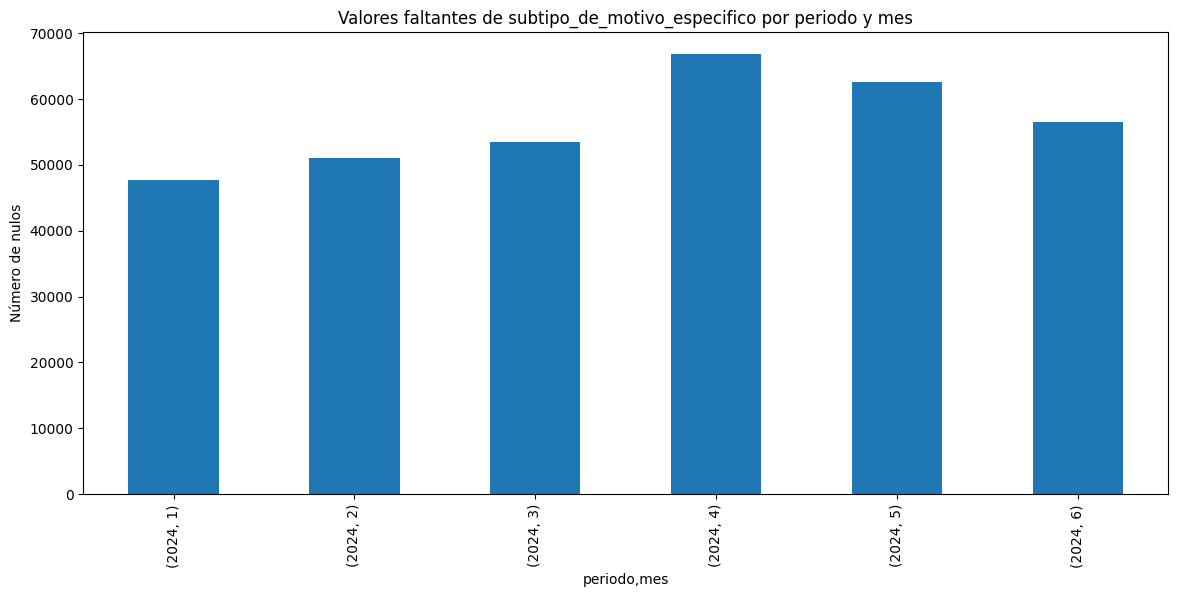

In [ ]:
# Ejemplo para pet_cod_mpio
missing_by_period = reclamos_quality_df.groupby(["periodo","mes"])["subtipo_de_motivo_especifico"].apply(lambda x: x.isna().sum())

missing_by_period.plot(kind="bar", figsize=(14,6))
plt.ylabel("Número de nulos")
plt.title("Valores faltantes de subtipo_de_motivo_especifico por periodo y mes")
plt.show()

In [ ]:
## Que harían ustedes ?

## Identificando la causa raiz y planteando soluciones
- Los registros anonimos, no son pasados del registro original
- Podemos intentar reconstruirlos con la siguiente lógica

Podemos definir una regla operacional y agregar una columna indicador. Se puede como anónimo cuando simultáneamente falten los códigos de procedencia de la petición y los códigos de tipo/subtipo del motivo específico (los cuatro nulos). De forma robusta, también se pueden comprobar las columnas de texto asociadas por si están presentes en el esquema.

In [ ]:

mask_base = (
    reclamos_quality_df["pet_cod_depto"].isna()
    & reclamos_quality_df["pet_cod_mpio"].isna()

)


mask_anonimo = mask_base

# Indicador booleano (nullable) y versión categórica compacta
reclamos_quality_df["es_anonimo"] = mask_anonimo.astype("boolean")


# (Opcional) Métrica rápida de control de calidad:
pct = 100 * reclamos_quality_df["es_anonimo"].mean()
print(f"Filas marcadas como anónimo: {pct:.2f}%")

Filas marcadas como anónimo: 0.27%


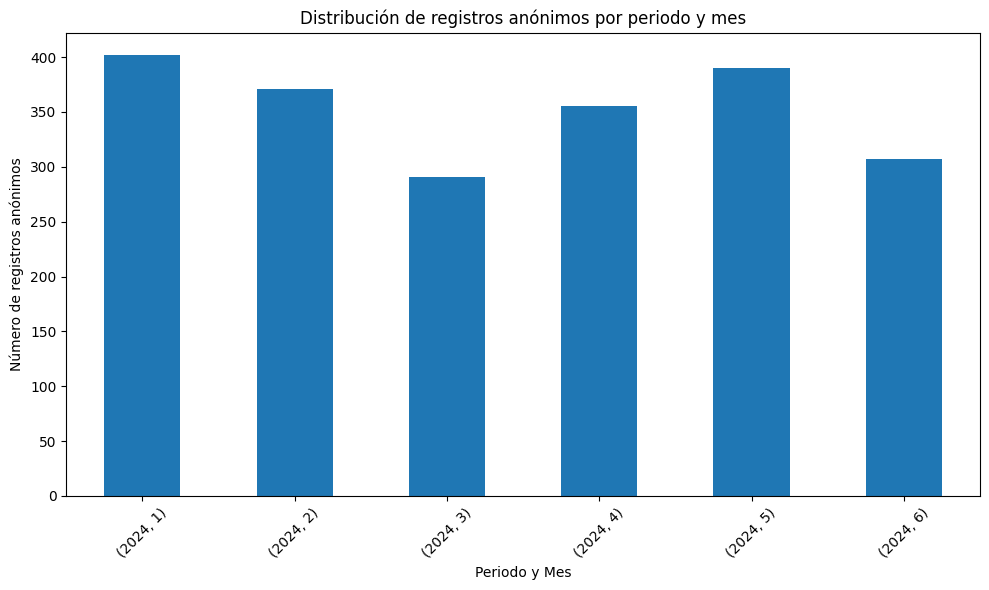

In [ ]:
import matplotlib.pyplot as plt

# Group by 'periodo' and 'mes' and count anonymous records
anonymous_by_month = reclamos_quality_df[reclamos_quality_df['es_anonimo']].groupby(['periodo', 'mes']).size()

# Create a histogram
anonymous_by_month.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de registros anónimos por periodo y mes')
plt.xlabel('Periodo y Mes')
plt.ylabel('Número de registros anónimos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
reclamos_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781601 entries, 0 to 781600
Data columns (total 38 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   periodo                       781601 non-null  Int16   
 1   mes                           781601 non-null  Int8    
 2   pqr_canal                     781601 non-null  category
 3   pet_cod_depto                 779485 non-null  Int8    
 4   pet_cod_mpio                  779485 non-null  Int32   
 5   id_afec                       781601 non-null  object  
 6   afec_parentesco               781601 non-null  category
 7   afec_genero                   781601 non-null  category
 8   afec_edad                     781601 non-null  Int32   
 9   afec_edadr                    781601 non-null  category
 10  afec_educ                     781601 non-null  category
 11  afec_regafiliacion            781601 non-null  category
 12  afec_getnico                  

In [ ]:
reclamos_quality_df.to_parquet('Reclamosq_2024.parquet',compression='zstd',index=False)

In [ ]:
!du -sh Reclamosq_2024.parquet

17M	Reclamosq_2024.parquet


In [ ]:
reclamos_df_partitioned = pd.read_parquet('Reclamosq_2024.parquet')
reclamos_df_partitioned.to_parquet('Reclamos_qp_2024', partition_cols=['afec_cod_depto'],compression='zstd',index=False)

In [ ]:
!du -sh Reclamos_qp_2024/*

5.7M	Reclamos_qp_2024/afec_cod_depto=11
3.1M	Reclamos_qp_2024/afec_cod_depto=13
3.1M	Reclamos_qp_2024/afec_cod_depto=15
3.1M	Reclamos_qp_2024/afec_cod_depto=17
2.7M	Reclamos_qp_2024/afec_cod_depto=18
3.0M	Reclamos_qp_2024/afec_cod_depto=19
2.9M	Reclamos_qp_2024/afec_cod_depto=20
3.0M	Reclamos_qp_2024/afec_cod_depto=23
3.7M	Reclamos_qp_2024/afec_cod_depto=25
2.8M	Reclamos_qp_2024/afec_cod_depto=27
3.1M	Reclamos_qp_2024/afec_cod_depto=41
2.8M	Reclamos_qp_2024/afec_cod_depto=44
2.9M	Reclamos_qp_2024/afec_cod_depto=47
5.3M	Reclamos_qp_2024/afec_cod_depto=5
3.1M	Reclamos_qp_2024/afec_cod_depto=50
2.9M	Reclamos_qp_2024/afec_cod_depto=52
3.0M	Reclamos_qp_2024/afec_cod_depto=54
2.9M	Reclamos_qp_2024/afec_cod_depto=63
3.2M	Reclamos_qp_2024/afec_cod_depto=66
3.5M	Reclamos_qp_2024/afec_cod_depto=68
2.9M	Reclamos_qp_2024/afec_cod_depto=70
3.2M	Reclamos_qp_2024/afec_cod_depto=73
4.4M	Reclamos_qp_2024/afec_cod_depto=76
3.4M	Reclamos_qp_2024/afec_cod_depto=8
2.7M	Reclamos_qp_2024/afec_cod_depto=81
2.

In [ ]:
!du -sh Reclamos_2024_partitioned/pet_cod_depto\=44

1.4M	Reclamos_2024_partitioned/pet_cod_depto=44


In [ ]:
!curl -L -k  https://mapas.supersalud.gov.co/arcgisportal/sharing/rest/content/items/b257c9907b754b0cabb55a32e706bdee/data -o /content/Reclamos_dos_2024.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  674M  100  674M    0     0  35.4M      0  0:00:19  0:00:19 --:--:-- 39.1M


In [ ]:
!head Reclamos_dos_2024.csv

﻿OBJECTID;periodo;mes;pqr_canal;pet_cod_depto;pet_cod_mpio;id_afec;afec_parentesco;afec_genero;afec_edad;afec_edadr;afec_educ;afec_regafiliacion;afec_getnico;afec_pobespecial;afec_cod_depto;afec_cod_mpio;ent_nombre;ent_tipovig_sns;ent_cod_sns;ent_alias_sn;ent_cod_depto;ent_cod_mpio;cod_macromot;macromotivo;cod_motgen;motivo_general;cod_motesp;motivo_especifico;cod_tipo_motesp;tipo_de_motivo_especifico;cod_subtipo_motesp;subtipo_de_motivo_especifico;patologia_1;patologia_tipo;cie_10;alto_costo;clasificacion_de_riesgo
1;2024;7;Web;05;05789;US- 000002469551;A nombre propio;MUJER;71;MAYOR DE 63 AÑOS ;No Aplica;Subsidiado;No Aplica;No Aplica;05;05789;COOSALUD;RÉGIMEN SUBSIDIADO;ESS024;COOSALUD;05;05789;01;"BARRERAS EN EL ACCESO A TECNOLOGÍAS Y SERVICIOS DE SALUD; Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO";0101;FALTA DE OPORTUNIDAD EN LA PRESTACIÓN DE TECNOLOGÍAS EN SALUD Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO;010101;FALTA DE OPORTUNIDAD EN LAS CI

In [ ]:
reclamos_dos_2024_df = pd.read_csv('Reclamos_dos_2024.csv',  na_values=['', 'NA', 'N/A', 'NO APLICA', 'NOAPLICA'], sep=';')

In [ ]:
dtype_mapping = {
    'OBJECTID': 'Int64',
    'periodo': 'Int16',
    'mes': 'Int8',
    'pet_cod_depto': 'Int8',
    'pet_cod_mpio': 'Int32',
    'afec_edad': 'Int32',
    'afec_cod_depto': 'Int32',
    'afec_cod_mpio': 'Int32',
    'ent_cod_sns': 'string',
    'ent_cod_depto': 'Int32',
    'ent_cod_mpio': 'Int32',
    'cod_macromot': 'Int32',
    'cod_motgen': 'Int32',
    'cod_motesp': 'Int32',
    'cod_tipo_motesp': 'Int32',
    'cod_subtipo_motesp': 'Int32'
}

for col, dtype in dtype_mapping.items():
    if dtype.startswith('Int'):
        reclamos_dos_2024_df[col] = pd.to_numeric(reclamos_dos_2024_df[col], errors='coerce').astype(dtype)
    else:
        reclamos_dos_2024_df[col] = reclamos_dos_2024_df[col].astype(dtype)

# Convertir los objetos en Categorias
categorical_cols = [
    'pqr_canal', 'afec_parentesco', 'afec_genero', 'afec_edadr', 'afec_educ',
    'afec_regafiliacion', 'afec_getnico', 'afec_pobespecial', 'ent_nombre',
    'ent_tipovig_sns', 'ent_alias_sn', 'macromotivo', 'motivo_general',
    'motivo_especifico', 'tipo_de_motivo_especifico',
    'subtipo_de_motivo_especifico', 'patologia_1', 'patologia_tipo',
    'cie_10', 'alto_costo', 'clasificacion_de_riesgo'
]

for col in categorical_cols:
    # Vallidar si la columna existe antes de convertir
    if col in reclamos_dos_2024_df.columns:
        reclamos_dos_2024_df[col] = reclamos_dos_2024_df[col].astype('category')

#Borrar campos innecesarios
reclamos_dos_2024_df.drop(columns=['OBJECTID'], inplace=True)
#Mostrar nuevos tipos y tamaño
display(reclamos_dos_2024_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946468 entries, 0 to 946467
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   periodo                       946468 non-null  Int16   
 1   mes                           946468 non-null  Int8    
 2   pqr_canal                     946468 non-null  category
 3   pet_cod_depto                 944680 non-null  Int8    
 4   pet_cod_mpio                  944680 non-null  Int32   
 5   id_afec                       946468 non-null  object  
 6   afec_parentesco               946468 non-null  category
 7   afec_genero                   946468 non-null  category
 8   afec_edad                     946468 non-null  Int32   
 9   afec_edadr                    946468 non-null  category
 10  afec_educ                     946468 non-null  category
 11  afec_regafiliacion            946468 non-null  category
 12  afec_getnico                  

None

In [ ]:
reclamos_dos_2024_df.to_parquet('Reclamos_dos_2024.parquet',compression='zstd',index=False)

In [ ]:
!ls *.parquet

Reclamos_2024.parquet  Reclamos_dos_2024.parquet  Reclamosq_2024.parquet


In [ ]:
from pathlib import Path

# 1. Cargar ambos archivos parquet
df1 = pd.read_parquet("Reclamos_dos_2024.parquet", engine="pyarrow")
df2 = pd.read_parquet("Reclamosq_2024.parquet", engine="pyarrow")

# 2. Unirlos en un único DataFrame
df_2024 = pd.concat([df1, df2], ignore_index=True)

# (Opcional) verificar filas
print("Total filas combinadas:", len(df_2024))

# 3. Asegurar tipo correcto en columna de partición
df_2024["afec_cod_depto"] = pd.to_numeric(df_2024["afec_cod_depto"], errors="coerce").astype("Int16")

# 4. Definir carpeta de salida
out_dir = Path("reclamos_unificado_parquet")
if out_dir.exists():
    import shutil; shutil.rmtree(out_dir)

# 5. Escribir dataset Parquet particionado por afec_cod_depto
df_2024.to_parquet(
    out_dir,
    engine="pyarrow",
    compression="zstd",   # snappy si quieres velocidad
    index=False,
    partition_cols=["afec_cod_depto"]
)

print("Archivos escritos en:", out_dir)

Total filas combinadas: 1728069
Archivos escritos en: reclamos_unificado_parquet


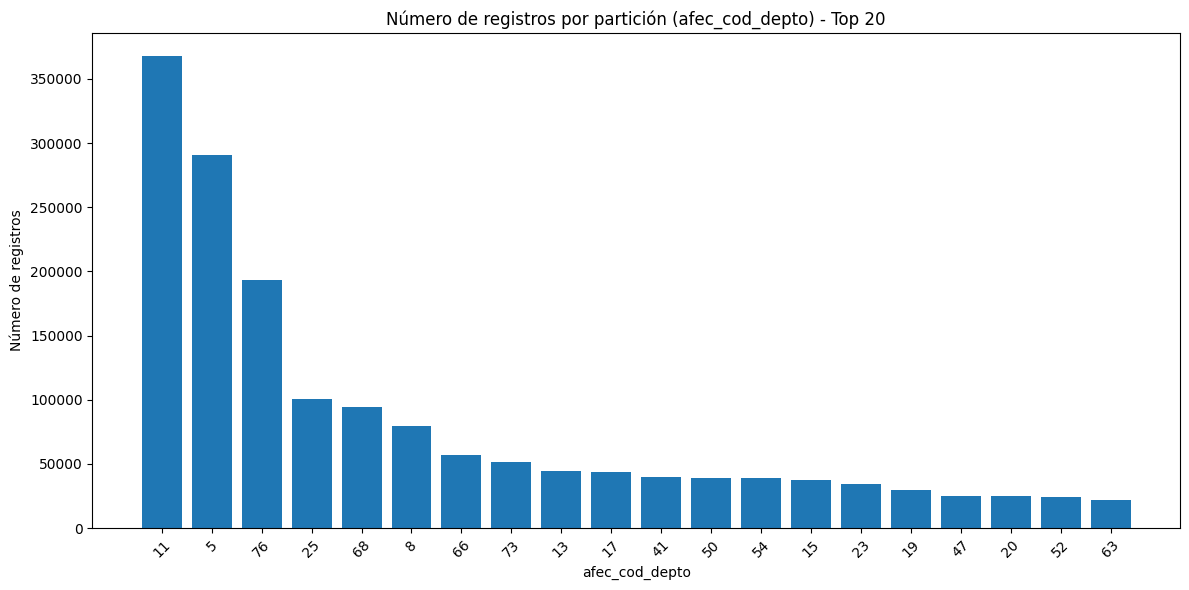

In [ ]:
# 4. Calcular registros por partición
count_part = (
    df_2024.groupby("afec_cod_depto")
    .size()
    .reset_index(name="num_registros")
    .sort_values("num_registros", ascending=False)
)

# 5. Graficar top 20 (para no saturar el eje)
plt.figure(figsize=(12,6))
plt.bar(count_part["afec_cod_depto"].astype(str).head(20),
        count_part["num_registros"].head(20))

plt.title("Número de registros por partición (afec_cod_depto) - Top 20")
plt.xlabel("afec_cod_depto")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!du -sh reclamos_unificado_parquet/afec_cod_depto\=11

8.2M	reclamos_unificado_parquet/afec_cod_depto=11


In [ ]:
hot_deptos = [11, 5, 76]
mask = df_2024["afec_cod_depto"].isin(hot_deptos)
df_2024.loc[mask, "bucket"] = (df_2024.loc[mask, "ent_cod_sns"].astype("category").cat.codes % 8).astype("Int8")
df_2024.loc[~mask, "bucket"] = pd.NA

df_2024.to_parquet(
    "reclamos_balanced",
    engine="pyarrow",
    compression="zstd",
    index=False,
    partition_cols=["afec_cod_depto","bucket"]
)

In [ ]:
!du -sh reclamos_balanced/afec_cod_depto\=11/*
!du -sh reclamos_balanced/afec_cod_depto\=25

2.3M	reclamos_balanced/afec_cod_depto=11/bucket=0
980K	reclamos_balanced/afec_cod_depto=11/bucket=1
940K	reclamos_balanced/afec_cod_depto=11/bucket=2
2.4M	reclamos_balanced/afec_cod_depto=11/bucket=3
2.2M	reclamos_balanced/afec_cod_depto=11/bucket=4
3.2M	reclamos_balanced/afec_cod_depto=11/bucket=5
1.4M	reclamos_balanced/afec_cod_depto=11/bucket=6
988K	reclamos_balanced/afec_cod_depto=11/bucket=7
3.4M	reclamos_balanced/afec_cod_depto=25


In [ ]:
# Read the partitioned parquet data, filtering for 'pet_cod_depto' == 44
# This will only read the data for the specified partition
reclamos_depto_44_df = pd.read_parquet('Reclamos_2024_partitioned', filters=[('pet_cod_depto', '=', 11.0)])

# Display the first few rows of the filtered DataFrame
display(reclamos_depto_44_df.head())

,OBJECTID,periodo,mes,pqr_canal,pet_cod_mpio,id_afec,afec_parentesco,afec_genero,afec_edad,afec_edadr,...,cod_tipo_motesp,tipo_de_motivo_especifico,cod_subtipo_motesp,subtipo_de_motivo_especifico,patologia_1,patologia_tipo,cie_10,alto_costo,clasificacion_de_riesgo,pet_cod_depto
0,3,2024,5,Web,11001.0,US- 000003606238,A nombre propio,HOMBRE,0,DE 0 A 5 AÑOS,...,1010308.0,PROCEDIMIENTOS NO QUIRÚRGICOS,1.010308e+09,IMAGENOLOGÍA,MATERNO INFANTIL,ATENCIÓN NIÑOS MENORES DE 5 AÑOS,CONTROL DE SALUD DE RUTINA DEL NIÑO,No aplica,SIMPLE,11
1,4,2024,6,Web,11001.0,US- 000001592546,Cónyuge,MUJER,62,DE 50 A 62 AÑOS,...,1030101.0,MEDICAMENTOS UPC,NaN,None,ENFERMEDADES OSTEOARTICULARES,OTROS,"ARTRITIS REUMATOIDE SEROPOSITIVA, SIN OTRA ESP...",No aplica,SIMPLE,11
2,8,2024,6,Telefónico,11001.0,US- 000003606241,Hijo (A),MUJER,78,MAYOR DE 63 AÑOS,...,1010103.0,ESPECIALIDADES MÉDICAS,1.010103e+09,OFTALMOLOGÍA,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PTERIGIÓN,No aplica,SIMPLE,11
3,9,2024,6,Web,11001.0,US- 000003606242,A nombre propio,HOMBRE,24,DE 18 A 24 AÑOS,...,1020308.0,PROCEDIMIENTOS NO QUIRÚRGICOS,1.020308e+09,OTROS PROCEDIMIENTOS NO QUIRÚRGICOS,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,"HERNIA INGUINAL UNILATERAL O NO ESPECIFICADA, ...",No aplica,SIMPLE,11
4,13,2024,3,Telefónico,11001.0,US- 000002626901,Madre,HOMBRE,4,DE 0 A 5 AÑOS,...,1020103.0,ESPECIALIDADES MÉDICAS,1.020103e+09,OFTALMOLOGÍA,MATERNO INFANTIL,ATENCIÓN NIÑOS MENORES DE 5 AÑOS,RETARDO EN DESARROLLO,No aplica,SIMPLE,11


In [ ]:
# Read the partitioned parquet data, filtering for 'pet_cod_depto' == 44
# This will only read the data for the specified partition
reclamos_depto_44 = pd.read_parquet('Reclamos_2024.parquet', filters=[('pet_cod_depto', '=', 11.0)])

# Display the first few rows of the filtered DataFrame
display(reclamos_depto_44.head())

,OBJECTID,periodo,mes,pqr_canal,pet_cod_depto,pet_cod_mpio,id_afec,afec_parentesco,afec_genero,afec_edad,...,motivo_especifico,cod_tipo_motesp,tipo_de_motivo_especifico,cod_subtipo_motesp,subtipo_de_motivo_especifico,patologia_1,patologia_tipo,cie_10,alto_costo,clasificacion_de_riesgo
0,3,2024,5,Web,11.0,11001.0,US- 000003606238,A nombre propio,HOMBRE,0,...,FALTA DE OPORTUNIDAD EN LA ATENCIÓN EN OTROS S...,1010308.0,PROCEDIMIENTOS NO QUIRÚRGICOS,1.010308e+09,IMAGENOLOGÍA,MATERNO INFANTIL,ATENCIÓN NIÑOS MENORES DE 5 AÑOS,CONTROL DE SALUD DE RUTINA DEL NIÑO,No aplica,SIMPLE
1,4,2024,6,Web,11.0,11001.0,US- 000001592546,Cónyuge,MUJER,62,...,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TEC...,1030101.0,MEDICAMENTOS UPC,NaN,None,ENFERMEDADES OSTEOARTICULARES,OTROS,"ARTRITIS REUMATOIDE SEROPOSITIVA, SIN OTRA ESP...",No aplica,SIMPLE
2,8,2024,6,Telefónico,11.0,11001.0,US- 000003606241,Hijo (A),MUJER,78,...,FALTA DE OPORTUNIDAD EN LAS CITAS O CONSULTAS,1010103.0,ESPECIALIDADES MÉDICAS,1.010103e+09,OFTALMOLOGÍA,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PTERIGIÓN,No aplica,SIMPLE
3,9,2024,6,Web,11.0,11001.0,US- 000003606242,A nombre propio,HOMBRE,24,...,NEGACIÓN EN LA ATENCIÓN EN OTROS SERVICIOS DE ...,1020308.0,PROCEDIMIENTOS NO QUIRÚRGICOS,1.020308e+09,OTROS PROCEDIMIENTOS NO QUIRÚRGICOS,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,"HERNIA INGUINAL UNILATERAL O NO ESPECIFICADA, ...",No aplica,SIMPLE
4,13,2024,3,Telefónico,11.0,11001.0,US- 000002626901,Madre,HOMBRE,4,...,NEGACIÓN EN LA ASIGNACIÓN DE CITAS O CONSULTAS,1020103.0,ESPECIALIDADES MÉDICAS,1.020103e+09,OFTALMOLOGÍA,MATERNO INFANTIL,ATENCIÓN NIÑOS MENORES DE 5 AÑOS,RETARDO EN DESARROLLO,No aplica,SIMPLE


# Tarea Completa
Group the dataframe `reclamos_df` by `afec_genero` and `mes`, calculate the percentage of each group, and create a pie chart using seaborn for each month showing the distribution of complaints by gender.

## Agrupar y Contar

### Subtask:
Group the `reclamos_df` DataFrame by `afec_genero` and `mes` and count the occurrences in each group.


**Reasoning**:
Group the dataframe by `afec_genero` and `mes` and count the occurrences to get the number of complaints for each gender in each month.



In [ ]:
reclamos_grouped = reclamos_df.groupby(['afec_genero', 'mes']).size().reset_index(name='count')
display(reclamos_grouped.head(10))

,afec_genero,mes,count
0,HOMBRE,1,45447
1,HOMBRE,2,49981
2,HOMBRE,3,49108
3,HOMBRE,4,62868
4,HOMBRE,5,59571
5,HOMBRE,6,53338
6,MUJER,1,65547
7,MUJER,2,70962
8,MUJER,3,70679
9,MUJER,4,91399


In [ ]:
reclamos_df['mes'].sort_values().unique()

array([1, 2, 3, 4, 5, 6])

## Calculate percentages

### Subtask:
Calculate the percentage of each gender within each month group.


**Reasoning**:
Calculate the percentage of each gender within each month group by grouping by month and applying a transformation to calculate the percentage.



In [ ]:
reclamos_grouped['percentage'] = reclamos_grouped.groupby('mes')['count'].transform(lambda x: (x / x.sum()) * 100)
display(reclamos_grouped.head(10))

,afec_genero,mes,count,percentage
0,HOMBRE,1,45447,40.945457
1,HOMBRE,2,49981,41.326079
2,HOMBRE,3,49108,40.996101
3,HOMBRE,4,62868,40.752721
4,HOMBRE,5,59571,40.801496
5,HOMBRE,6,53338,41.153324
6,MUJER,1,65547,59.054543
7,MUJER,2,70962,58.673921
8,MUJER,3,70679,59.003899
9,MUJER,4,91399,59.247279


## Visualize the data

### Subtask:
Iterate through each month and create a pie chart showing the percentage distribution of complaints by gender for that month.


**Reasoning**:
Iterate through each month in the grouped dataframe, filter the data for the current month, and create a pie chart showing the percentage distribution of complaints by gender.



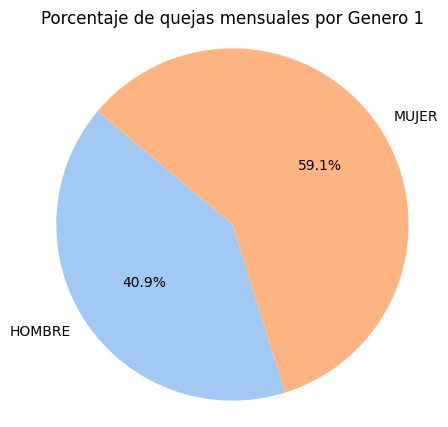

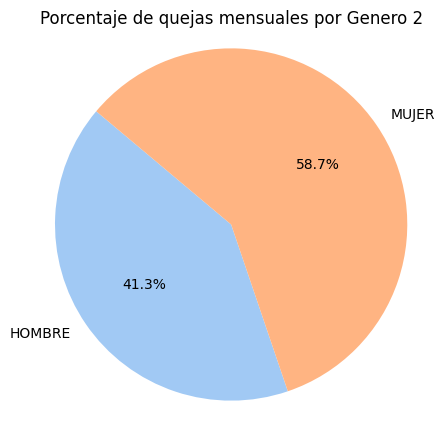

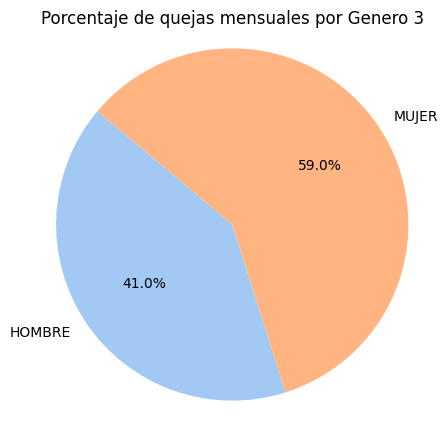

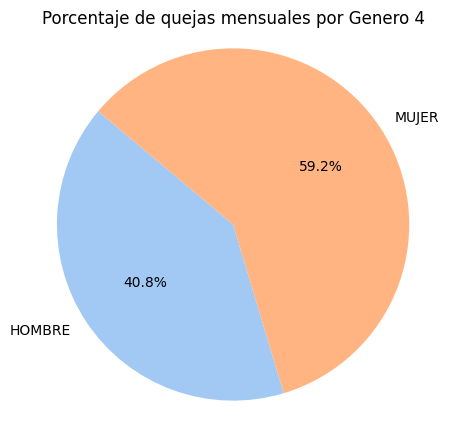

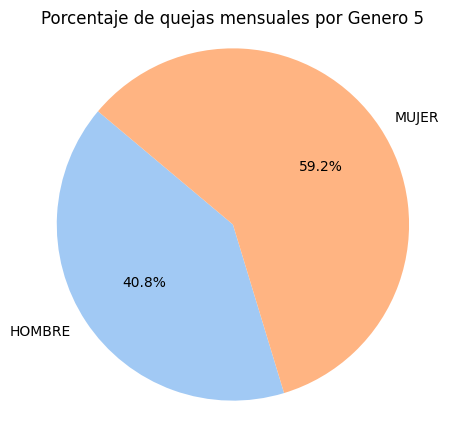

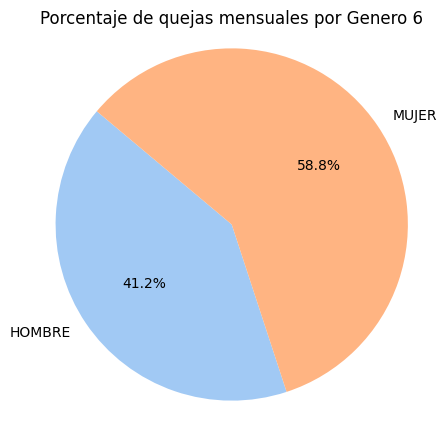

In [ ]:
# Get unique months
unique_months = reclamos_grouped['mes'].unique()

# Iterate through each month and create a pie chart
for month in unique_months:
    # Filter data for the current month
    monthly_data = reclamos_grouped[reclamos_grouped['mes'] == month]

    # Create a pie chart
    plt.figure(figsize=(5, 5))
    plt.pie(monthly_data['percentage'], labels=monthly_data['afec_genero'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel')[0:len(monthly_data)])
    plt.title(f'Porcentaje de quejas mensuales por Genero {month}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Task
Analyze the `reclamos_df` dataframe by grouping by `afec_genero` and `mes`, and create pie graphs using seaborn for each group and percentage. Additionally, include an analysis by `afec_edad` for values between 40 and 60.

## Filter by age

### Subtask:
Filter the `reclamos_df` DataFrame to include only records where `afec_edad` is between 40 and 60 (inclusive).


**Reasoning**:
Filter the `reclamos_df` DataFrame to include only records where `afec_edad` is between 40 and 60 (inclusive) and display the head of the filtered dataframe.



In [ ]:
reclamos_filtered_age = reclamos_df[(reclamos_df['afec_edad'] >= 40) & (reclamos_df['afec_edad'] <= 60)]
display(reclamos_filtered_age.head())

,OBJECTID,periodo,mes,pqr_canal,pet_cod_depto,pet_cod_mpio,id_afec,afec_parentesco,afec_genero,afec_edad,...,motivo_especifico,cod_tipo_motesp,tipo_de_motivo_especifico,cod_subtipo_motesp,subtipo_de_motivo_especifico,patologia_1,patologia_tipo,cie_10,alto_costo,clasificacion_de_riesgo
6,7,2024,5,Web,85.0,85250.0,US- 000003606240,A nombre propio,MUJER,43,...,NEGACIÓN EN LA ATENCIÓN EN OTROS SERVICIOS DE ...,1020309.0,PROCEDIMIENTOS QUIRÚRGICOS,1.020309e+09,OTROS PROCEDIMIENTOS QUIRÚRGICOS,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,OTROS PROBLEMAS RELACIONADOS CON SERVICIOS MÉD...,No aplica,SIMPLE
13,14,2024,6,Web,5.0,5679.0,US- 000003606245,A nombre propio,HOMBRE,60,...,FALTA DE OPORTUNIDAD EN LA ATENCIÓN EN OTROS S...,1010309.0,PROCEDIMIENTOS QUIRÚRGICOS,1.010309e+09,OTROS PROCEDIMIENTOS QUIRÚRGICOS,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,HERNIA INGUINAL,No aplica,SIMPLE
14,15,2024,6,Personalizado,52.0,52678.0,US- 000003606246,A nombre propio,MUJER,42,...,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE CIT...,1030203.0,ESPECIALIDADES MÉDICAS,1.030203e+09,CIRUGÍA DE MAMA Y TEJIDOS BLANDOS - MASTOLOGÍA,ENFERMEDADES CRÓNICAS NO TRANSMISIBLES- FACTOR...,OBESIDAD,MASTOPATÍA QUÍSTICA DIFUSA,No aplica,SIMPLE
16,17,2024,4,Telefónico,25.0,25754.0,US- 000003606247,A nombre propio,HOMBRE,59,...,NEGACIÓN EN LA ASIGNACIÓN DE CITAS O CONSULTAS,1020103.0,ESPECIALIDADES MÉDICAS,1.020103e+09,OFTALMOLOGÍA,ENFERMEDADES CRÓNICAS NO TRASMISIBLES CARDIOVA...,HTA (HIPERTENSIÓN ARTERIAL),"CATARATA SENIL, NO ESPECIFICADA",No aplica,SIMPLE
17,18,2024,6,Web,5.0,5197.0,US- 000003606248,A nombre propio,HOMBRE,60,...,FALTA DE OPORTUNIDAD EN LAS CITAS O CONSULTAS,1010103.0,ESPECIALIDADES MÉDICAS,1.010103e+09,UROLOGÍA,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,PROBLEMAS RELACIONADOS CON FACILIDADES DE ATEN...,CALCULO DEL RIÑÓN,No aplica,SIMPLE


## Group and count

### Subtask:
Group the filtered DataFrame by `afec_genero` and `mes` and count the occurrences in each group.


**Reasoning**:
Group the filtered dataframe by 'afec_genero' and 'mes' and count the occurrences in each group to prepare for calculating percentages.



In [ ]:
reclamos_filtered_grouped = reclamos_filtered_age.groupby(['afec_genero', 'mes']).size().reset_index(name='count')
display(reclamos_filtered_grouped.head())

,afec_genero,mes,count
0,HOMBRE,1,11780
1,HOMBRE,2,13069
2,HOMBRE,3,12456
3,HOMBRE,4,16240
4,HOMBRE,5,15226


## Calculate percentages

### Subtask:
Calculate the percentage of each gender within each month group from the filtered data.


**Reasoning**:
Calculate the percentage of each gender within each month group by grouping by month and applying a transformation to calculate the percentage.



In [ ]:
reclamos_filtered_grouped['percentage'] = reclamos_filtered_grouped.groupby('mes')['count'].transform(lambda x: (x / x.sum()) * 100)
display(reclamos_filtered_grouped.head())

,afec_genero,mes,count,percentage
0,HOMBRE,1,11780,36.721843
1,HOMBRE,2,13069,37.290989
2,HOMBRE,3,12456,36.545006
3,HOMBRE,4,16240,36.317284
4,HOMBRE,5,15226,36.355388


## Visualize the data

### Subtask:
Iterate through each month in the filtered and grouped data and create a pie chart showing the percentage distribution of complaints by gender for that month.


**Reasoning**:
Iterate through each month in the filtered and grouped data, filter the data for the current month, and create a pie chart showing the percentage distribution of complaints by gender.



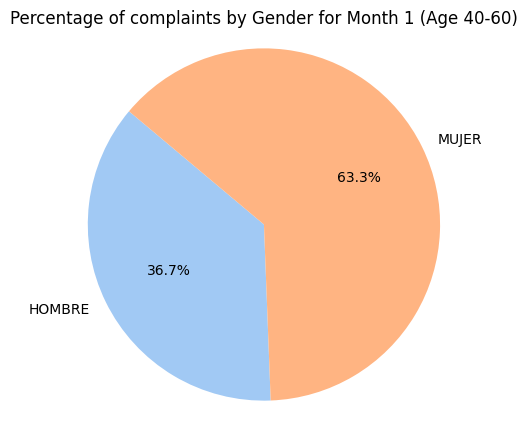

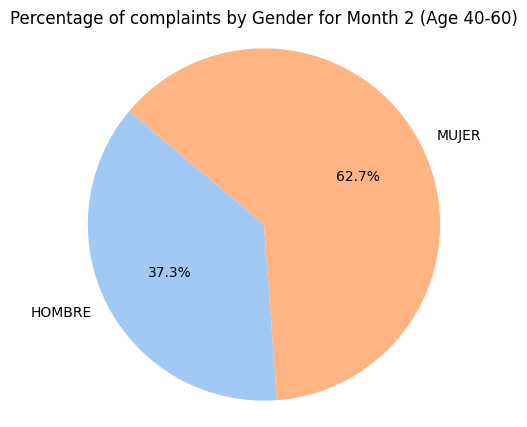

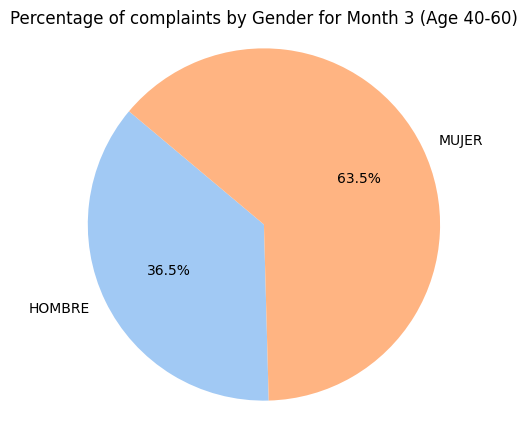

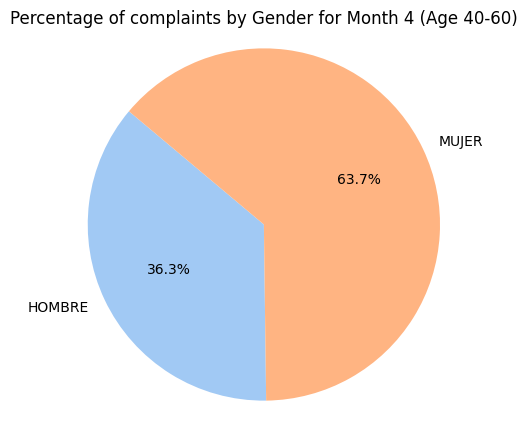

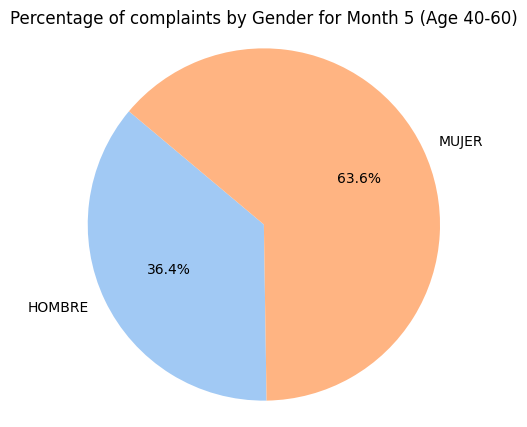

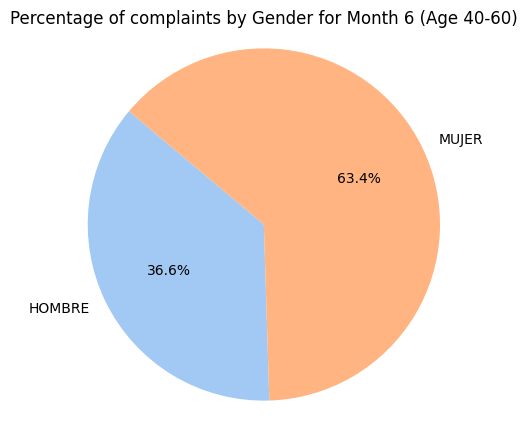

In [ ]:
# Get unique months from the filtered and grouped data
unique_months_filtered = reclamos_filtered_grouped['mes'].unique()

# Iterate through each month and create a pie chart
for month in unique_months_filtered:
    # Filter data for the current month
    monthly_filtered_data = reclamos_filtered_grouped[reclamos_filtered_grouped['mes'] == month]

    # Create a pie chart
    plt.figure(figsize=(5, 5))
    plt.pie(monthly_filtered_data['percentage'], labels=monthly_filtered_data['afec_genero'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel')[0:len(monthly_filtered_data)])
    plt.title(f'Percentage of complaints by Gender for Month {month} (Age 40-60)')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

## Summary:

### Data Analysis Key Findings

*   The analysis focused on complaints from individuals aged 40 to 60.
*   The data was grouped by gender (`afec_genero`) and month (`mes`) to understand the distribution of complaints within this age group.
*   For each month, the percentage of complaints by gender was calculated.
*   Pie charts were generated for each month, visualizing the percentage breakdown of complaints by gender for individuals aged 40-60.

### Insights or Next Steps

*   Analyze the pie charts to identify months with significant gender imbalances in complaints within the 40-60 age group.
*   Explore the reasons behind any observed gender disparities in complaints for specific months.
